<h1><center>Modelling and Engineering of Nanoscale Materials <br> Exercises session 10: MLIPs in practice - 2025 </center></h1>
<center>massimo.bocus@ugent.be,  arnout.maet@ugent.be, thomas.nicholas@ugent.be</center>

<details>
<summary><strong>How to start JupyterLab with the course environment</strong> (click to expand)</summary>
<br>

1. **Number of cores (and default memory) per node**  
   Set this to **> 2 cores** (e.g. choose 4 cores or more).

2. **JupyterLab version**  
   Select **`None (advanced)`**.

3. **Custom code**  
   Paste the following line into the *Custom code* box:

   ```bash
   source /kyukon/data/gent/courses/2025/nanoscale_E006800/input/tensorpotential_env/activate.sh
   ```
   <br>


4. Start the JupyterLab session.
Once your notebook opens, the course Python environment is already activated.

</details>

In [1]:
! cp -r /data/gent/courses/2025/nanoscale_E006800/input/input_session10 ./

In [1]:
import os
import yaml
import time
import logging
import subprocess
from typing import Final
from pathlib import Path

logger = logging.getLogger("pyiron_log")
logger.setLevel(logging.ERROR)

os.environ["CUDA_VISIBLE_DEVICES"] = "-1"

out_dir = Path("outputs")
out_dir.mkdir(parents=True, exist_ok=True)

fig_dir = Path("figures")
fig_dir.mkdir(parents=True, exist_ok=True)

import ase
import pyiron
import numpy as np
import matplotlib.pyplot as plt
from ase.build import bulk, molecule
from ase.md.langevin import Langevin
from ase.io.trajectory import Trajectory
from ase.md.velocitydistribution import MaxwellBoltzmannDistribution

from pyiron import Project, ase_to_pyiron
from tensorpotential.calculator import grace_fm
from tensorpotential.calculator import TPCalculator

from input_session10.misc import apply_style
from input_session10.mlip import submit_grace_training, kill_grace_training, training_status
from input_session10.utils import view, load_trajectory, parity_plot
from input_session10.label import label_with_vasp, atoms_from_group

apply_style()

%matplotlib inline

E0000 00:00:1766585882.682552   35232 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1766585883.089066   35232 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1766585884.566667   35232 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1766585884.566700   35232 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1766585884.566702   35232 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1766585884.566703   35232 computation_placer.cc:177] computation placer already registered. Please check linka

## Introduction

In the previous session you saw how to generate datasets and train machine-learned interatomic potentials (MLIPs) for a specific material of interest, exploiting physical symmetries to obtain more data-efficient models. However, even with the substantial speed-up offered by MLIPs over the underlying *ab initio* calculations, it is still rather costly to start from scratch for every new system. In addition, it quickly becomes impractical if we have to train a separate MLIP each time we introduce a new material or molecular component.

In this notebook, we will explore the use of so-called *foundation models*, which are designed to address exactly these issues. Instead of targeting extremely high accuracy for a single material, these models are trained on very large and chemically diverse datasets drawn from many different systems. The resulting potentials are therefore intended to be broadly applicable across a wide range of materials and chemistries, albeit at the cost of some loss in accuracy for any given system. As we will see, this loss can often be mitigated by *fine-tuning* the foundation model towards the particular application of interest.

To keep the calculations computationally tractable on a CPU-only environment, we will use the Graph Atomic Cluster Expansion (GRACE) MLIP architecture. You can find the documentation [here](https://gracemaker.readthedocs.io/en/latest/), and we have included two relevant papers for the architecture and foundation models below [1,2]. In the first half of the notebook, you will be leveraging foundation models to simulate water in a periodic box and evaluating the accuracy by performing your own reference DFT calculations. In the second half, we will make use of a dataset of aluminium-lithium (Al-Li) binary compounds reported in ref. [3] to explore one way of quantifying uncertainty in our model's predictions, and compare its performance to the foundation models' predictions.

<div class="alert alert-block alert-warning">
<b>Educational Objectives</b> <br> 
    
(1) Demonstrate foundation models can be used "out-of-the-box" to simulate an arbritary number of water molecules in a periodic box, and evaluate the efficiency and accuracy of these simulations.<br>
(2)  Explore fine-tuning the foundation model to improve upon these predictions with relatively little extra training data.<br>
(3) Use ensembles of MLIP models for estimating uncertainty in energy predictions.<br>
(4) Use MLIP models for phonon calculations, comparing the results between purpose-fit and foundation models.
</div>


References
----------
[1] [Bochkarev, Lysogorskiy, and Drautz; *Phys. Rev. X*, **14**, 021036 (2024)](https://journals.aps.org/prx/abstract/10.1103/PhysRevX.14.021036)

[2] [Lysogorskiy, Bochkarev, and Drautz; arXiv:508.17936v1[cond-mat.mtrl-sci] (2025)](https://arxiv.org/html/2508.17936v1)

[3] [Menon *et al.*, *npj Comput. Mater.*, **10**, 261 (2024)](https://www.nature.com/articles/s41524-024-01441-0)

---

## Exercise 1: Molecular dynamics with foundation MLIPs

<div class="alert alert-block alert-success">
<b>Complete the following tasks using the code below:</b> <br>   
<ol type='1'>
<li> Generate a water molecule at the center of a 15$\times$15$\times$15 periodic simulation box using <code>ase</code>, and perform a molecular dynamics simulation of the water molecule using the Langevin thermostat implemented in <code>ase</code> using a 1-layer (local) GRACE foundation model. How does the geometry compare to your custom model from the last session?</li>
<br>
<li>Now construct simulation boxes with increasing numbers of water molecules, being careful to avoid overlapping molecules. Evaluate the scaling behaviour (i.e., timing) of the MLIP model as a function of the number of atoms (keeping the density fixed). Is it how you would expect? How does it compare to DFT?</li>
<br>
<li><b>Optional.</b> What happens if you instead allow the density to vary?</li>
<br>
<li>To evaluate the accuracy of the foundation model, perform DFT single point calculations on configurations produced from the previous two parts. Also evaluate the GRACE energy/forces on the same structures and visualise the differences between the models using a parity plot. How does the model perform?</li>
</ol>
</div>

### Question 1

We need a periodic box because we will obtain the reference labels using VASP. You can visualise the <code>ase.Atoms</code> object using the <code>view(my_atoms_object)</code> function provided.

In [2]:
#TODO: create a water molecule at the centre of a 15x15x15 simulation box.
#TIP: you can view it with: view(water_mol)
water_mol = molecule('H2O')
water_mol.cell = [15,15,15]
water_mol.pbc = True
water_mol.center()

You can access the GRACE foundation models directly and attach them to the <code>ase.Atoms</code> objects:

```python
calc_grace = grace_fm("GRACE-1L-OAM")
atoms.calc = calc_grace
...
```

We suggest running for at least 1,000 steps with a 0.5 fs timestep. You can set the friction coefficient to <code>0.01/ase.units.fs</code>.

So that we can store and reload the geometry throughout the simulation, we will make use of <code>ase</code>'s <code>Trajectory()</code> object. It can be attached like so:

```python
# write the geometry of water_mol object to a trajectory file "outputs/water.traj"
traj = Trajectory("outputs/water.traj", "w", water_mol)

# randomly initialise the velocities at 300 K.
MaxwellBoltzmannDistribution(atoms, temperature_K=300)

# setup the Langevin object for MD simulation
dynamics = Langevin( ... )

# instruct the MD simulation to write a frame every 20 intervals
dynamics.attach(traj.write, interval=20)
dynamics.run(1_000)

# afterwards, close the trajectory object.
traj.close()
```

In [3]:
#TODO: load the GRACE foundation model, attach to your atoms object, and run a short MD.
calc_grace = grace_fm("GRACE-1L-OAM")
water_mol.calc = calc_grace

Using cached GRACE model from /data/gent/courses/2025/nanoscale_E006800/input/tensorpotential_env/cache/GRACE-1L-OAM
Model license: Academic Software License


In [4]:
# write the geometry of water_mol object to a trajectory file "outputs/water.traj"
traj = Trajectory("outputs/water.traj", "w", water_mol)

# randomly initialise the velocities at 300 K.
MaxwellBoltzmannDistribution(water_mol, temperature_K=300)

# setup the Langevin object for MD simulation
dynamics = Langevin(water_mol,timestep = 0.5 * ase.units.fs, temperature_K = 300, friction = 0.01/ase.units.fs)

# instruct the MD simulation to write a frame every 20 intervals
dynamics.attach(traj.write, interval=20)
dynamics.run(1_000)

# afterwards, close the trajectory object.
traj.close()

I0000 00:00:1766585937.029048   35232 service.cc:152] XLA service 0x5591d5a5a150 initialized for platform Host (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1766585937.029114   35232 service.cc:160]   StreamExecutor device (0): Host, Default Version
I0000 00:00:1766585940.624721   35232 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


You can then load that trajectory using:

```python
frames = load_trajectory("outputs/water.traj")
```

which will give a ```list[ase.Atoms]``` object.


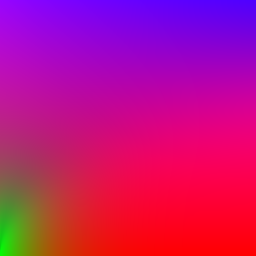

In [5]:
#TODO: load in the frames from the trajectory and analyse/plot geometric properties.
frames = load_trajectory("outputs/water.traj")
view(frames[-1])

### Question 2

In this section we use water clusters to investigate how the computational cost of the MLIP scales with system size.

Generate clusters containing an increasing number of water molecules and run short molecular dynamics simulations with the MLIP.

<div class="alert alert-block alert-info">
  <b>Hint:</b> To ensure your scaling tests are not overshadowed by the effect of the average number of neighbours between different configurations, keep the density of the system constant as you increase the number of molecules!
</div>

<div class="alert alert-block alert-danger">
  <b>Warning:</b> Be careful to ensure there aren't too highly unphysical 
  interactions in your starting models or the simulations are sure to fail!
</div>

Timing sections of code in Python is easy:

```python

import time

tick = time.perf_counter()

# run some code to time...
time.sleep(3)

tock = time.perf_counter()

print(f"Elapsed time = {tock-tick:.2f} s")

>>> Elapsed time = 3.00 s
```


In [6]:
def make_water_cluster(
    n_molecules: int,
    box_size: float = 10.0,
    min_com_distance: float = 3.0,
    seed: int | None = 42
) -> ase.Atoms:
    """
    Generate a water cluster in a cubic box with the specified number 
    of water molecules. Applies a simple cutoff distance to prevent 
    overlap of the molecules C.O.M.s.

    Parameters
    ----------
    n_molecules 
        Number of water molecules to include.
    box_size
        Simulation box cell parameter (Å).
    min_com_distance
        The minimum distance between the new molecule and other C.O.M.s.
    seed
        Random seed for the generation of angles and translations.
    """
    np.random.seed = seed

    extra_water = molecule('H2O')
    extra_water.cell = [box_size,box_size,box_size]
    extra_water.pbc = True
    
    extra_water.center()
    
    waters = [extra_water]
    

    for _ in range(n_molecules-1):
        attempts = 0

        while attempts < 10_000:
            pos = np.random.uniform(0,box_size,size=(1,3))

            extra_water = molecule('H2O')
        
            extra_water.euler_rotate(phi=np.random.uniform(0,360),theta=np.random.uniform(0,360),psi=np.random.uniform(0,360))
            extra_water.positions += pos

            extra_water.cell = [box_size,box_size,box_size]
            extra_water.pbc = True

            
            if all((np.linalg.norm(water.get_center_of_mass() - extra_water.get_center_of_mass()))>= min_com_distance for water in waters):

                waters.append(extra_water)
                
                break

            attempts += 1

        if attempts == 10_000:
            raise RuntimeError("Could not place all atoms in without overlap, make the cell bigger you dumb fuck!!")

    cluster = waters[0]

    for water in waters[1:]:
        cluster += water
    
    cluster.cell = [box_size,box_size,box_size]
    cluster.pbc = True
    
    return cluster


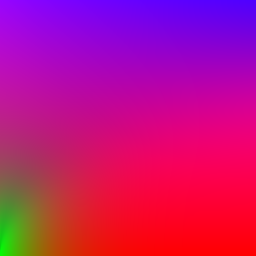

In [9]:
view(make_water_cluster(15,seed=6))

In [10]:
#TODO: use your water cluster builder to construct simulation boxes with varying 
#      numbers of molecules, and run short (500 step) MD runs. Remember to time
#      how long each simulation takes.

#TIP:  You might want to use higher tempeature (800 K) to diversify the structures
#      so we can use them for training later.

#TIP:  You could try keeping a constant 30 Å^3 / molecule

box_size = lambda n_molecules: (n_molecules * 40)**(1/3)

n = [3,5,10,15,20]
t = []

for n_molecules in n:

    cluster = make_water_cluster(n_molecules,box_size=box_size(n_molecules))
    cluster.calc = calc_grace
    
    # write the geometry of water_mol object to a trajectory file "outputs/water.traj"
    traj = Trajectory(f"outputs/water{n_molecules}.traj", "w", cluster)
    
    # randomly initialise the velocities at 300 K.
    MaxwellBoltzmannDistribution(cluster, temperature_K=300)
    
    # setup the Langevin object for MD simulation
    dynamics = Langevin(cluster,timestep = 0.5 * ase.units.fs, temperature_K = 800, friction = 0.01/ase.units.fs)
    
    # instruct the MD simulation to write a frame every 20 intervals
    dynamics.attach(traj.write, interval=20)
    
    tick = time.perf_counter()
    dynamics.run(500)
    tock = time.perf_counter()

    t.append(tock-tick)
    
    # afterwards, close the trajectory object.
    traj.close()


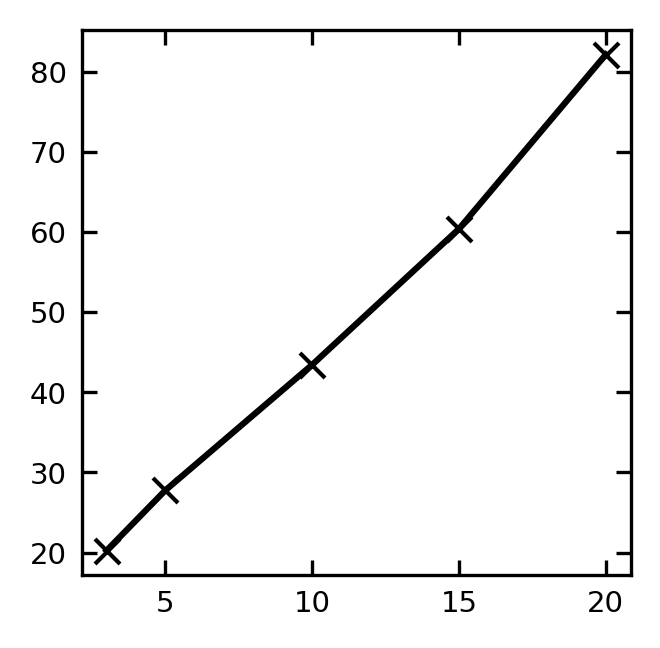

In [11]:
#TODO: plot your scaling results
plt.plot(n,t,marker="x")
plt.show()

In [12]:
#OPTIONAL
#TODO: now fix the number of molecules (say, 8) and vary the density.


### Question 3

Now that we have generated a short molecular dynamics trajectory using the GRACE foundation model, we would like to assess how accurate this MLIP is compared with our *ab initio* reference. A common way to do this is to:

1. “Label” each configuration in the trajectory with reference DFT energies and forces.
2. Compute the corresponding MLIP energies for the same structures.
3. Compare the MLIP properties to the DFT computed properties.

In [13]:
# pyiron session for labelling structures with VASP.
pr = Project('session_mlip')

To assist with the labelling and collecting of single point simulations, we have created a helper function label_with_vasp() which will automatically submit your jobs for labelling (via pyiron). E.g., 

```python
# load the frames
frames = load_trajectory("outputs/water.traj")

# submit the vasp jobs via PyIron
all_jobs = label_with_vasp(
    pr, frames, 
    job_name="water_molecules", 
    run_time=60*30, n_cores=16,
    cluster="doduo",
)
```

<div class="alert alert-block alert-info">
  <b>Hint:</b> Try as a group to distribute your jobs over both the shinx and doduo clusters to avoid too long delays!
</div>

By default, these VASP calculations are performed with the PBE functional and a plane-wave energy cut-off of 520 eV to match that of the foundation model datasets. Note, there may still be other differences in the exact setup of these calculations, but the results will be illustrative nonetheless.


In [14]:
! cp -r /data/gent/courses/2025/nanoscale_E006800/input/projects_input/potpaw_PBE/{H,O} \
      /data/gent/courses/2025/nanoscale_E006800/members/${USER}/pyiron/resources/vasp/potentials/potpaw_PBE/

In [15]:
#TODO: load some frames and submit them for labelling with VASP.
# load the frames
frames = load_trajectory("outputs/water.traj")

# submit the vasp jobs via PyIron
all_jobs = label_with_vasp(
    pr, frames, 
    job_name="water_molecules", 
    run_time=60*30, n_cores=16,
    cluster="doduo",
)
#HINT: you can include many single water molecule ones, but many-molecule 
#      clusters will take more time (for DFT and for training later!).
frames = load_trajectory("outputs/water3.traj")

# submit the vasp jobs via PyIron
all_jobs = label_with_vasp(
    pr, frames, 
    job_name="water_cluster_3", 
    run_time=60*30, n_cores=16,
    cluster="doduo",
)


Submitted 51 jobs!
Submitted 26 jobs!


In [60]:
frames = load_trajectory("outputs/water5.traj")

all_jobs = label_with_vasp(
    pr, frames, 
    job_name="water_cluster_5", 
    run_time=60*10, n_cores=16,
    cluster="doduo",
)

Submitted 26 jobs!


When these jobs have run, we can gather them using another helper function:

```python
atoms = (
    atoms_from_group(pr, group_name="water_molecules") +
    atoms_from_group(pr, group_name="water_cluster_4") +
    ...
)
print(f"Dataset size = {len(atoms)} ({sum(len(a) for a in atoms)} atoms)")
```

This will collect any jobs from the specified group that have finished.

In [61]:
#TODO: now get your dataset back.
atoms = (
    atoms_from_group(pr, group_name="water_molecules") +
    atoms_from_group(pr, group_name="water_cluster_3") +
    atoms_from_group(pr, group_name="water_cluster_5")
)

print(f"Dataset size = {len(atoms)} ({sum(len(a) for a in atoms)} atoms)")

2025-12-24 16:05:59,430 - pyiron_log - WARNING - Could not access indices, returning None!
2025-12-24 16:05:59,445 - pyiron_log - WARNING - Could not access indices, returning None!
2025-12-24 16:05:59,656 - pyiron_log - WARNING - Could not access indices, returning None!
2025-12-24 16:05:59,671 - pyiron_log - WARNING - Could not access indices, returning None!
2025-12-24 16:05:59,890 - pyiron_log - WARNING - Could not access indices, returning None!
2025-12-24 16:05:59,905 - pyiron_log - WARNING - Could not access indices, returning None!
2025-12-24 16:06:00,114 - pyiron_log - WARNING - Could not access indices, returning None!
2025-12-24 16:06:00,129 - pyiron_log - WARNING - Could not access indices, returning None!
2025-12-24 16:06:00,336 - pyiron_log - WARNING - Could not access indices, returning None!
2025-12-24 16:06:00,351 - pyiron_log - WARNING - Could not access indices, returning None!
2025-12-24 16:06:00,553 - pyiron_log - WARNING - Could not access indices, returning None!

Dataset size = 102 (762 atoms)


/kyukon/data/gent/courses/2025/nanoscale_E006800/members/vsc48515/input_session10/label.py:188: UserWarning: Gathered 25/26 jobs.
  warnings.warn(f"Gathered {len(complete_atoms)}/{len(atoms)} jobs.")


Labelling those configurtaions with the MLIP model is easy. Simply attach the calculator as before, and call the relevant functions. Typically, we store per-structure properties in the ```ase.Atoms.info``` dictionary and per-atom properties in the ```ase.Atoms.arrays``` dictionary. E.g.,

```python 
atoms.info["my_energy_label"] = atoms.get_potential_energy()
atoms.arrays["my_forces_label"] = atoms.get_forces()
```

In [62]:
#TODO: iterate through your dataset, compute the energies and forces with the GRACE 
#      foundation model, and store them in the the info and arrays dictionaries, respectively.
for atom in atoms:
    atom.calc = calc_grace
    atom.info["energy_grace"] = atom.get_potential_energy()
    atom.arrays["forces_grace"] = atom.get_forces()

Before we can make a meaningful comparison, we need to address an important detail: **isolated atom energies**. The raw DFT total energy of a system includes an almost constant contribution from the individual atoms (e.g. the energy of an isolated O atom, an isolated H atom, etc.), plus the contribution from the bonding and interaction between them. When training and evaluating MLIPs, it is standard practice to remove these element-wise atomic reference energies and work instead with **binding** or **formation** energies:

$$
E_\text{binding} = E_\text{total} - \sum_i n_i E_i^\text{isolated},
$$

where $n_i$ is the number of atoms of element $i$, and $E_i^\text{isolated}$ is the energy of a single isolated atom of that element at the same level of theory.

To obtain these reference atomic energies for our chosen DFT setup, you should carry out separate calculations on isolated O and H atoms in a large box. You can then use the resulting atomic reference energies to correct all energies in the water trajectory.

In [30]:
#TODO: make isolated atoms in large boxes and label with DFT.
O = molecule('O')
O.cell = [15,15,15]
O.pbc = True
O.center()

H = molecule('H')
H.cell = [15,15,15]
H.pbc = True
H.center()

# submit the vasp jobs via PyIron
all_jobs = label_with_vasp(
    pr,[O,H], 
    job_name="Single_Atoms", 
    run_time=60*3, n_cores=4,
    cluster="doduo",
)


Submitted 2 jobs!


Collect those isolated values into a dictionary containing: {chemical symbol: isolated atom energy}

In [63]:
#TODO: load the energies, store in dictionary, and correct the energies for each configuration.
single_atoms = atoms_from_group(pr, group_name="Single_Atoms")


e0 = {"O": single_atoms[0].info["energy_ref"]
      ,"H":single_atoms[1].info["energy_ref"]
     }

def correct_energies(
    dataset: list[ase.Atoms], 
    e0: dict[str, float], 
    suffix: str = "ref"
) -> None:
    """
    Computes the binding energy for each frame in the dataset (in-place).
    
    Parameters
    ----------
    dataset
        A list of ase.Atoms objects to compute for
    e0
        A dictionary of element: atomic energy for all elements in the dataset
    suffix
        The suffix of the DFT-derived energy label
    """

    for atoms in dataset:

        # compute the binding energy and store it in the info dictionary
        
        atoms.info[f"energy_{suffix}_corrected"] = atoms.info[f"energy_{suffix}"] - np.sum([e0[atom] for atom in atoms.get_chemical_symbols()])


correct_energies(atoms, e0)

2025-12-24 16:06:59,289 - pyiron_log - WARNING - Could not access indices, returning None!
2025-12-24 16:06:59,304 - pyiron_log - WARNING - Could not access indices, returning None!
2025-12-24 16:06:59,498 - pyiron_log - WARNING - Could not access indices, returning None!
2025-12-24 16:06:59,512 - pyiron_log - WARNING - Could not access indices, returning None!


You can then check your error metrics using a parity plot that compares the predicted properties from the foundation model against the (corrected) DFT values.

```python
fig, ax, metrics = parity_plot(
    atoms,
    quantity="energy",
    ref_tag="ref_corrected",
    pred_tag="grace-1l-oam",
)
```

where <code>atoms</code> is your list of <code>ase.Atoms</code> objects, assumed to contain both <code>"energy_ref_corrected"</code> and <code>"energy_grace-1l-oam"</code> in the <code>atoms.info</code> dictionary, and similarly for the forces:

```python
fig, ax, metrics = parity_plot(
    atoms,
    quantity="forces",
    ref_tag="ref",
    pred_tag="grace-1l-oam",
)
```

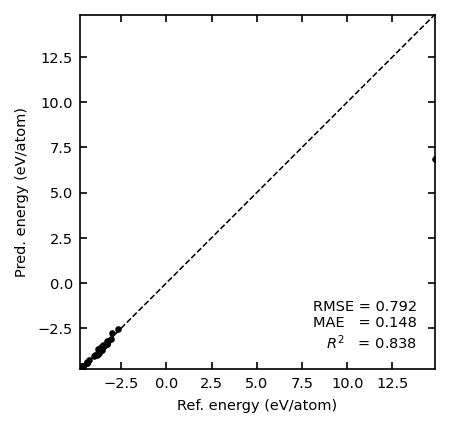

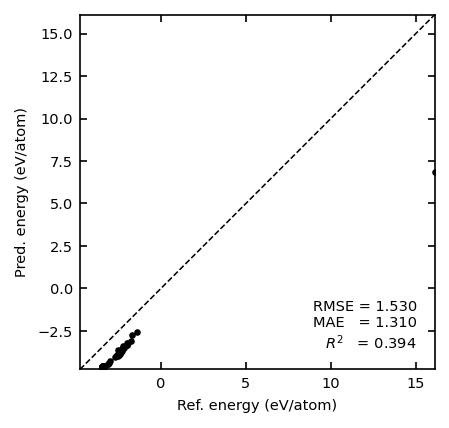

In [73]:
#TODO: analyse the errors using parity plots for the energies and forces
fig, ax, metrics = parity_plot(
    atoms,
    quantity="energy",
    ref_tag="ref",
    pred_tag="grace",
)

fig, ax, metrics = parity_plot(
    atoms,
    quantity="energy",
    ref_tag="ref_corrected",
    pred_tag="grace",
)

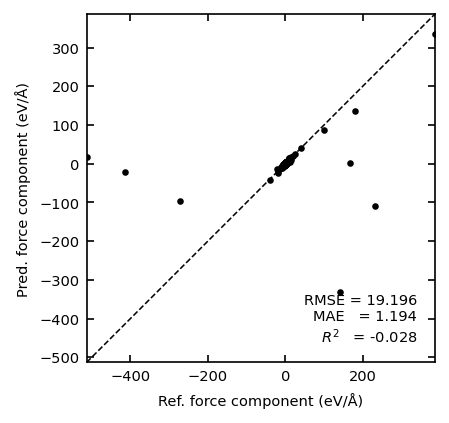

In [75]:
fig, ax, metrics = parity_plot(
    atoms,
    quantity="forces",
    ref_tag="ref",
    pred_tag="grace",
)

---

## Exercise 2: Fine-tuning a foundation model

In the previous exercise we treated the GRACE-1L-OAM foundation model as a fixed, pre-trained calculator and simply assessed how well it reproduced our DFT reference energies and forces for the water trajectory. We now go one step further and **adapt** this foundation model to our specific system by *fine-tuning* it on the DFT-labelled configurations we have just generated.

### What do we mean by “fine-tuning”?

Fine-tuning refers to taking a model that has already been pre-trained and continuing the training on a much smaller, system-specific dataset. During fine-tuning we update the model parameters slightly, nudging the foundation model towards higher accuracy for this particular type of water environment, while still retaining much of its original transferability. This is usually far cheaper and more data-efficient than training a new MLIP from scratch.

<div class="alert alert-block alert-success">
<b>Complete the following tasks using the code below:</b> <br>   
<ol type='1'>
<li> Using the input template below, fine-tune the GRACE foundation model on your own dataset. From the output, how many trainable parameters are there in the model? How do the test errors vary as a function of the number of epochs? What should you be concerned about regarding your dataset size? </li>
<br>
<li>Evaluate the errors of your new fine-tuned model on the dataset. How do they compare to the foundation model?</li>
</ol>
</div>

In [77]:
for atom in atoms:
    atom.calc = None

In [78]:
def prepare_dataframe(dataset, suffix: str = "ref"):
    import pandas as pd
    data = pd.DataFrame({
        "ase_atoms": dataset,
        "energy": [atoms.info[f"energy_{suffix}"][0] for atoms in dataset],
        "energy_corrected": [atoms.info[f"energy_{suffix}_corrected"][0] for atoms in dataset],
        "forces": [atoms.arrays[f"forces_{suffix}"][0] for atoms in dataset],
    })

    return data

In [79]:
from sklearn.model_selection import train_test_split

train, test = train_test_split(atoms, train_size=0.7)

df = prepare_dataframe(train)
df.to_pickle("outputs/train.pkl.gz")

df = prepare_dataframe(test)
df.to_pickle("outputs/test.pkl.gz")

### Setting up the GRACE fine-tuning run

The next step is to define a YAML configuration file (`input.yaml`) that tells GRACE how to perform the fine-tuning. The key ingredients are:

- **Random seed and cutoff**
  - `seed: 42` ensures reproducibility of the training.
  - `cutoff: 6` Å sets the spatial range of the interactions considered by the potential.

- **Data block**
  - `filename` and `test_filename` point to the training and test datasets we just wrote.
  - `save_dataset: False` avoids writing out additional processed copies of the data.

- **Potential block**
  - `finetune_foundation_model: GRACE-1L-OAM` specifies that we start from this pre-trained model.
  - `reduce_elements: True` and `elements: [H, O]` restrict the potential to only the elements present in our system, which simplifies the model and speeds up training.

- **Fit block (optimisation settings)**
  - `optimizer: Adam`, `batch_size: 4`, and the `opt_params` configure the stochastic optimiser (learning rate, gradient clipping, etc.).
  - The `loss` section defines a **combined loss** on energies and forces, both using a Huber loss (robust to outliers), with equal weighting.
  - `maxiter: 50` limits the number of optimisation steps.
  - The `scheduler_params` control the learning-rate schedule during training.

In [80]:
training_config = """
seed: 42
cutoff: 6

data:
    filename: outputs/train.pkl.gz
    test_filename: outputs/test.pkl.gz
    save_dataset: False

potential:
  finetune_foundation_model: GRACE-1L-OAM
  reduce_elements: True
  elements: [H, O]
  scale: False
  reference_energy: 0

fit:
    optimizer: Adam
    batch_size: 4
    train_max_n_buckets: 10
    test_max_n_buckets: 8
    opt_params: {learning_rate: 0.001, clipnorm: 1.0}
    eval_init_stats: True
    loss: {
        energy: { type: huber, weight: 1,  delta: 0.01},
        forces: { type: huber, weight: 1,  delta: 0.01},
    }
    maxiter: 50
    scheduler_params: {
        "warmup_epochs": 2,
        "cold_learning_rate": 0.1,
        "minimal_learning_rate": 0.0001
    }
"""

with open("input.yaml", "w") as f:
    f.write(training_config)

So that you don't have to sit and watch the training in real time (as stimulating as that might be!) we have prepared some helper functions to:

- (i) submit the job;
- (ii) monitor the progress of the job; and
- (iii) kill the job if required.

Please note, if you do kill the job, you will not have access to the relevant training logs or saved <code>TensorFlow</code> model for the rest of this exercise.

```python
from input_session10.mlip import (
    submit_grace_training,
    kill_grace_training, 
    training_status
)

# submit a training job.
p = submit_grace_training()

# check the status of running job.
training_status()

# kill the current running job.
kill_grace_training()
```

<div class="alert alert-block alert-info">
  <b>Hint:</b> You can directly observe the training log in the file "grace_train.log".
</div>

In [81]:
#TODO: run a fine-tuning job
from input_session10.mlip import (
    submit_grace_training,
    kill_grace_training, 
    training_status
)

In [82]:
# submit a training job.
p = submit_grace_training()

Started training with PID 46613
Logging to grace_train.log
Please note: this function is running in the background and the performance will be affected by any other load placed on your resources!


In [87]:
# check the status of running job.
training_status()

finished (PID 46613, exit code 0), iteration 50/50


After the fine-tuning run has completed, you can load the recorded metrics from `grace_water_ft/42/train_metrics.yaml` and plot the evolution of:

- `rmse/depa`: the root-mean-square error in energy per atom, and  
- `rmse/f_comp`: the root-mean-square error in force components,

as a function of optimisation steps. You can load yaml files e.g.,

```python
with open("grace_water_ft/42/train_metrics.yaml") as f:
    data = yaml.safe_load(f)
```

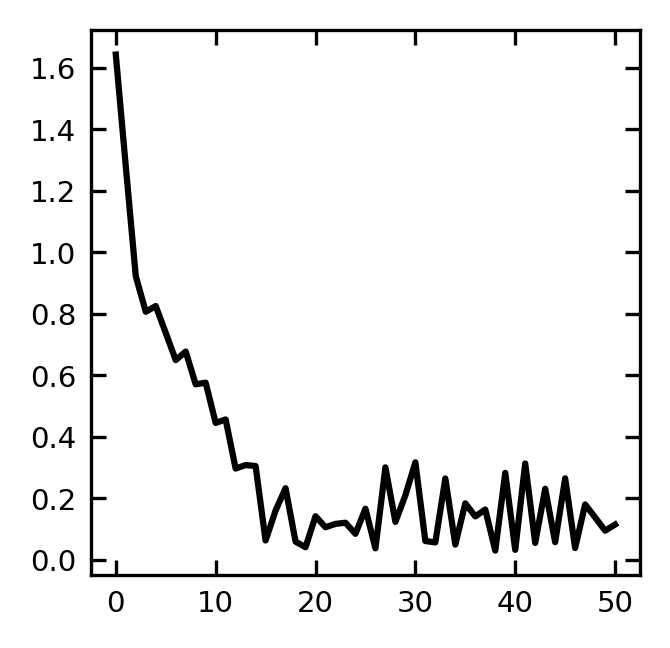

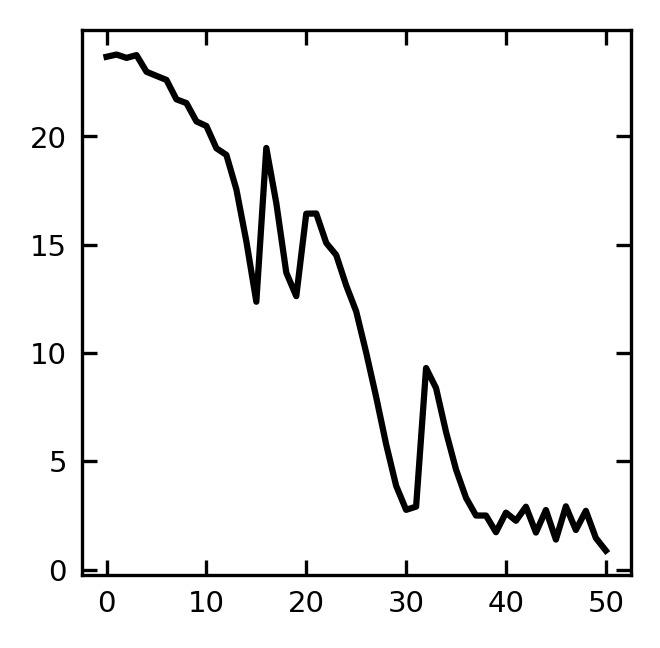

In [94]:
#TODO: load the energy and force errors from the training.yaml 
#      and plot their evolution as a function of epochs.
with open("grace_water_ft/42/train_metrics.yaml") as f:
    data = yaml.safe_load(f)

plt.plot([d["rmse/depa"] for d in data])
plt.show()

plt.plot([d["rmse/f_comp"] for d in data])
plt.show()

### Question 2

Now you can recompute the MLIP predictions for all configurations and generate new parity plots for energies and forces, now comparing DFT (reference) vs **fine-tuned GRACE** predictions.

You can load your fine-tuned model into an `ase` calculator using:

```python
calc_grace_ft = TPCalculator("grace_water_ft/42/saved_model/")
```

In [96]:
#TODO: load the new model and re-compute the energy/force errors
calc_grace_ft = TPCalculator("grace_water_ft/42/saved_model/")

for atom in atoms:
    atom.calc = calc_grace_ft
    atom.info["energy_grace_trained"] = atom.get_potential_energy()
    atom.arrays["forces_grace_trained"] = atom.get_forces()


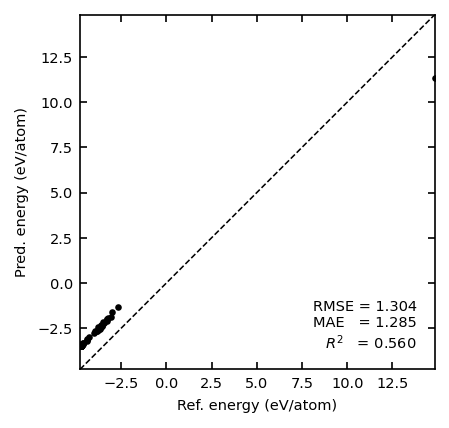

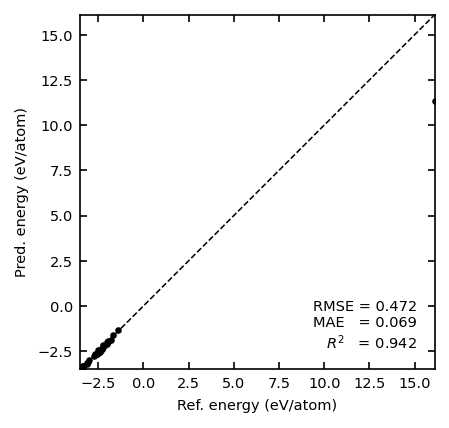

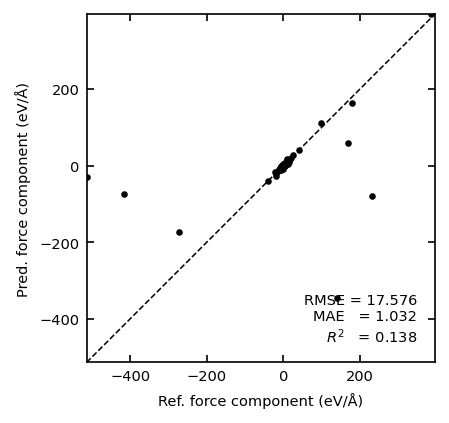

In [101]:
fig, ax, metrics = parity_plot(
    atoms,
    quantity="energy",
    ref_tag="ref",
    pred_tag="grace_trained",
)

fig, ax, metrics = parity_plot(
    atoms,
    quantity="energy",
    ref_tag="ref_corrected",
    pred_tag="grace_trained",
)

fig, ax, metrics = parity_plot(
    atoms,
    quantity="forces",
    ref_tag="ref",
    pred_tag="grace_trained",
)

---
## Exercise 3: uncertainty in predictions

In this exercise we explore **uncertainty estimation** for MLIPs using an **ensemble of models**. Even if a single MLIP provides very accurate energies and forces on average, it generally does **not** tell us when its predictions are likely to be unreliable, e.g. when we leave the region of configuration space covered by the training data.

A simple and widely used approach is to train several models with the same architecture and training data, but with different random seeds. For a new configuration, we then evaluate the energy with each model, and use the **spread** (e.g. standard deviation) of the predictions as a proxy for the model’s uncertainty. This approach is usually called "query by committee" in machine-learning.

Here we use an ensemble of models trained on a binary system containing aluminium and lithium (Al-Li) from reference [2] to illustrate this idea. The dataset was generated in reference [3], and consists of ~3000 structures. The models have already been fitted for you; we will use them to evaluate the system energy for fcc Al as a function of lattice parameters and examine how the predicted uncertainty changes as we move away from the region where the models were trained.

<div class="alert alert-block alert-success">
<b>Complete the following tasks using the code below:</b> <br>   
<ol type='1'>
<li> Generate a series of bulk aluminium structures with a cubic FCC structure but varying lattice parameters (between 2 and 8 Å). Use an ensemble calculator from the provided models with different random seeds and evaluate the energy and standard deviation of the energy predictions. Given that the equilibrium lattice parameter of bulk aluminium with the FCC structure is ~4.1 Å, what can you infer about the training dataset?</li>
<br>
<li>By referring back to the training input.yaml file, can you understand why the models become interpolative again at larger lattice parameters?</li>
</ol>
</div>

---
Below we show the training configuration that was used to obtain the Al–Li models in this ensemble. You do **not** need to re-run the training in this notebook, but the configuration is provided so that you can see the key design choices:

- The model uses the `GRACE_2LAYER` preset with specific angular and radial basis settings.
- Energies, forces, and stresses are all included in the loss with different weights, using a Huber-type loss.
- An **energy-based weighting** and convex-hull-based scheme are used to emphasise structures that are close to thermodynamic stability.
- Training is done with the Adam optimiser and a learning-rate schedule, for up to 500 iterations.

This configuration is representative of a practical MLIP fit: several hyperparameters are tuned, but once the setup is chosen, it can be reused to train multiple independent models (with different seeds) to form an ensemble.


In [102]:
training_config = """
seed: 4
cutoff: 5.0

data:
  filename: input_session10/collected.pkl
  test_size: 0.05
  reference_energy: 0
  save_dataset: False

potential:
  preset: GRACE_2LAYER
  kwargs: {lmax: [3, 2], max_order: 3, n_rad_max: [20, 32], n_mlp_dens: 8}
  scale: True

fit:
    loss: {
        energy: { weight: 1, type: huber , delta: 0.01 },
        forces: { weight: 5, type: huber , delta: 0.01 },
        stress: { weight: 0.1, type: huber , delta: 0.01 },
    }
    weighting: { type: energy_based, DElow: 1.0, DEup: 10.0, DFup: 50.0, DE: 1.0, DF: 1.0, wlow: 0.75, energy: convex_hull, seed: 42}
    maxiter: 500
    optimizer: Adam
    opt_params: {
        learning_rate: 0.01,
        amsgrad: True,
        use_ema: True,
        ema_momentum: 0.99,
        weight_decay: null,
        clipvalue: 1.0,
    }
    eval_init_stats: True
    scheduler_params: {
        "warmup_epochs": 2,
        "cold_learning_rate": 0.1,
        "minimal_learning_rate": 0.05
    }
    compute_convex_hull: True
    batch_size: 32
    train_shuffle: True
"""

with open("input-LiAl.yaml", "w") as f:
    f.write(training_config)

In [ ]:
# launch the trainining job with the cli command.
# note: we perform the fit, save the model, and then move outputs to "grace_al_li"
#!gracemaker && gracemaker -r -s && mv seed/4 grace_al_li/

Now construct an ensemble calculator by passing a list of model directories to `TPCalculator`:

```python
calc_ens = TPCalculator(model=[
    f"input_session10/grace_al_li/{seed}/saved_model/"
    for seed in range(5)
])
```

Internally, this calculator:

- evaluates the energy and forces with **each** model in the ensemble, and
- returns the **mean** as the final prediction, together with additional quantities such as the **standard deviation of the energy**, stored in `results['energy_std']`.

These can be retrieved by:

```python
atoms.calc = calc_ens
energy = atoms.get_potential_energy()
energy_std = atoms.calc.results['energy_std']
```

In [103]:
#TODO: load your ensenmble calculator.
calc_ens = TPCalculator(model=[
    f"input_session10/grace_al_li/{seed}/saved_model/"
    for seed in range(5)
])

Use this ensemble to compute the energy of bulk aluminium with an FCC cubic lattice structure as a function of the lattice constant. At each lattice constant, record:

- the mean energy per atom, and  
- the standard deviation $\sigma(E)$ across the ensemble.

In [141]:
#TODO: calculate the energy / std_dev for bulk Al (cubic FCC lattice) as a function of lattice parameter.
#TIP: a range of ~2 — 8 Å lattice parameter is sufficient!
lattice_parameters = np.linspace(2,8,100)

energy_list=[]
estd_list=[]

for a in lattice_parameters:
    Al = pr.create.structure.bulk("Al","fcc",a)
    Al.calc = calc_ens

    energy_list.append(Al.get_potential_energy())
    estd_list.append(Al.calc.results['energy_std'])
    



#FIXME!

estd_list = np.array(estd_list)
energy_list = np.array(energy_list)

To classify where the model is likely to be trustworthy, we introduce a simple **uncertainty threshold** on the energy standard deviation, $\sigma(E)$. Points with

- $\sigma(E) < \sigma_\text{thr}$ are labelled as **interpolation**, i.e. the model ensemble is confident and we expect to be within (or close to) the training domain.
- $\sigma(E) \ge \sigma_\text{thr}$ are labelled as **extrapolation**, where the ensemble disagrees more strongly and we should treat the predictions with caution.

This is, of course, a heuristic: the exact value of the threshold is problem-dependent. Here $\sigma_\text{thr} = 0.1\ \text{eV/atom}$ is suitable to highlight how the uncertainty grows as we move away from the equilibrium lattice constant.

---

To visualise these results, plot the evolution of the system energy as a function of lattice parameter and highlight regions of interpolation and extrapolation.

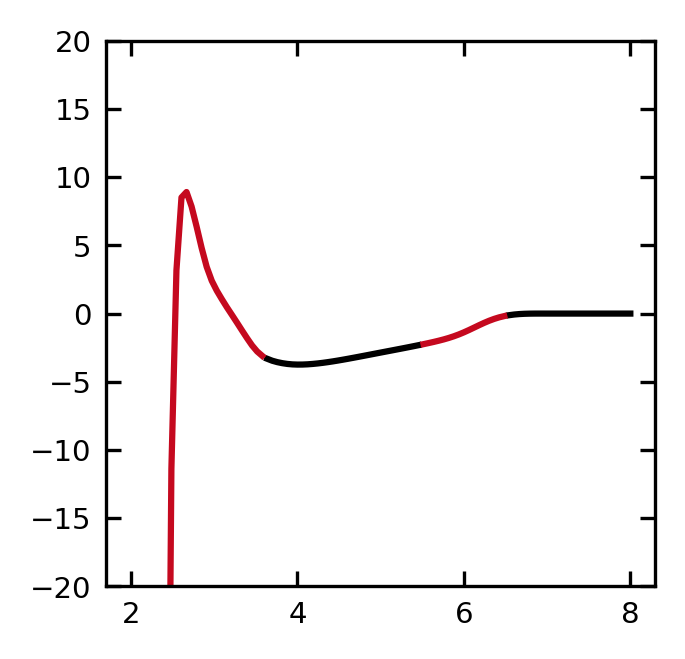

In [144]:
#TODO: plot the results, visualising when the model is interpolative or extrapolative.

e_std_threshold = 0.1
mask = estd_list < e_std_threshold

#FIXME!

plt.plot(lattice_parameters,np.where(mask, energy_list, np.nan))
plt.plot(lattice_parameters,np.where(~mask, energy_list, np.nan))
plt.ylim(-20,20)
plt.show()

---

## Exercise 4: some properties with MLIPs

In the final exercise we use our MLIPs not just as fast surrogates for single-point energies, but as general atomistic calculators. In particular, we will:

- relax the crystal structure using a geometry optimiser,
- compute phonon band structures and densities of states via finite displacements, and
- compare the predictions of a system-specific Al–Li model with those of a foundation model that has been pre-trained on a broad range of materials.

This demonstrates how modern MLIPs can be integrated seamlessly into standard atomistic workflows (structure optimisations, vibrational analysis, etc.), and how foundation models can provide reasonable property predictions even when we have not performed a dedicated fit for the system of interest.

### Background: phonons and vibrational spectra

In a crystal, atoms are not fixed at their equilibrium positions. At finite temperature they vibrate about these positions. If the vibrations are small, we can linearise the equations of motion and describe them as a set of normal modes. Each normal mode is a collective motion of all the atoms in the crystal.

In a periodic solid, these normal modes are labelled by:

- a wave vector $\mathbf{q}$ in the Brillouin zone, and  
- a branch index (which of the $3N$ modes per unit cell we mean, where $N$ is the number of atoms in the primitive cell).

The quanta of these vibrational modes are called phonons. They play a central role in:

- heat capacity and thermal conductivity,
- thermal expansion,
- many aspects of phase stability.

To study phonons we usually look at two related objects:

- The **phonon band structure**: phonon energy (or frequency) as a function of $\mathbf{q}$ along a chosen high-symmetry path in the Brillouin zone, analogous to an electronic band structure.
- The **phonon density of states (DOS)**: how many vibrational modes there are per energy (or frequency) interval, integrated over the whole Brillouin zone.

In this exercise, we will use MLIPs as the force provider in a finite-displacement phonon calculation, and then compare the resulting phonon band structures and DOS from a system-specific model and a foundation model.

<div class="alert alert-block alert-success">
<b>Complete the following tasks using the code below:</b> <br>   
<ol type='1'>
<li>Load one of the Al-Li models to use as an <code>ase</code> calculator. Perform a geometry optimisation allowing the atomic positions and cell to relax. Compute the phonon band structure and the corresponding phonon density of states. From your phonon band structure and DOS, what can you conclude about the dynamical stability of the relaxed structure?</li>
<br>
<li> Repeat the same analysis with the GRACE foundation model. How do the results differ?</li>
</ol>
</div>

First, generate a bulk aluminium structure using ASE.

In [151]:
#TODO: generate a bulk aluminium structure
Al = pr.create.structure.bulk("Al")

You can load the pre-trained MLIP model and use it to perform a geometry optimisation in ASE.

```python
from ase.optimize import BFGS, FIRE
from ase.filters import FrechetCellFilter

calc = TPCalculator("input_session10/grace_al_li/0/saved_model/")
atoms.calc = calc

# perform a geometry optimisation while relaxing the cell and atomic positions
BFGS(FrechetCellFilter(atoms)).run()
```

In [152]:
#TODO: optimise the positions and cell shape.
from ase.optimize import BFGS, FIRE
from ase.filters import FrechetCellFilter

calc = TPCalculator("input_session10/grace_al_li/0/saved_model/")
Al.calc = calc

# perform a geometry optimisation while relaxing the cell and atomic positions
BFGS(FrechetCellFilter(Al)).run()

      Step     Time          Energy          fmax
BFGS:    0 17:53:07       -3.739849        0.416084
BFGS:    1 17:53:08       -3.746230        0.297806
BFGS:    2 17:53:10       -3.752205        0.038878


np.True_

Next, we use the relaxed structure as input to a **phonon calculation** based on finite displacements. The `Phonons` class in ASE:

1. builds a supercell of the primitive unit cell,
2. applies small displacements to each atom,
3. evaluates the resulting forces with the calculator, and
4. assembles the dynamical matrix and vibrational frequencies.

From this we can obtain both the **phonon band structure** along a chosen high-symmetry path in the Brillouin zone and the **phonon density of states (DOS)**.

For example, for a 7$\times$7$\times$7 supercell phonon calculation:

```python
from ase.phonons import Phonons

N = 7
ph = Phonons(atoms, calc, supercell=(N, N, N), delta=0.05)
ph.run()
ph.read(acoustic=True)
ph.clean()
```

In [159]:
#TODO: perform the phonon calculation for a 7x7x7 supercell.
from ase.phonons import Phonons

N = 7
ph = Phonons(Al, calc, supercell=(N, N, N), delta=0.05)
ph.run()
ph.read(acoustic=True)
ph.clean()

7

We can the get the band structure using our phonon class:

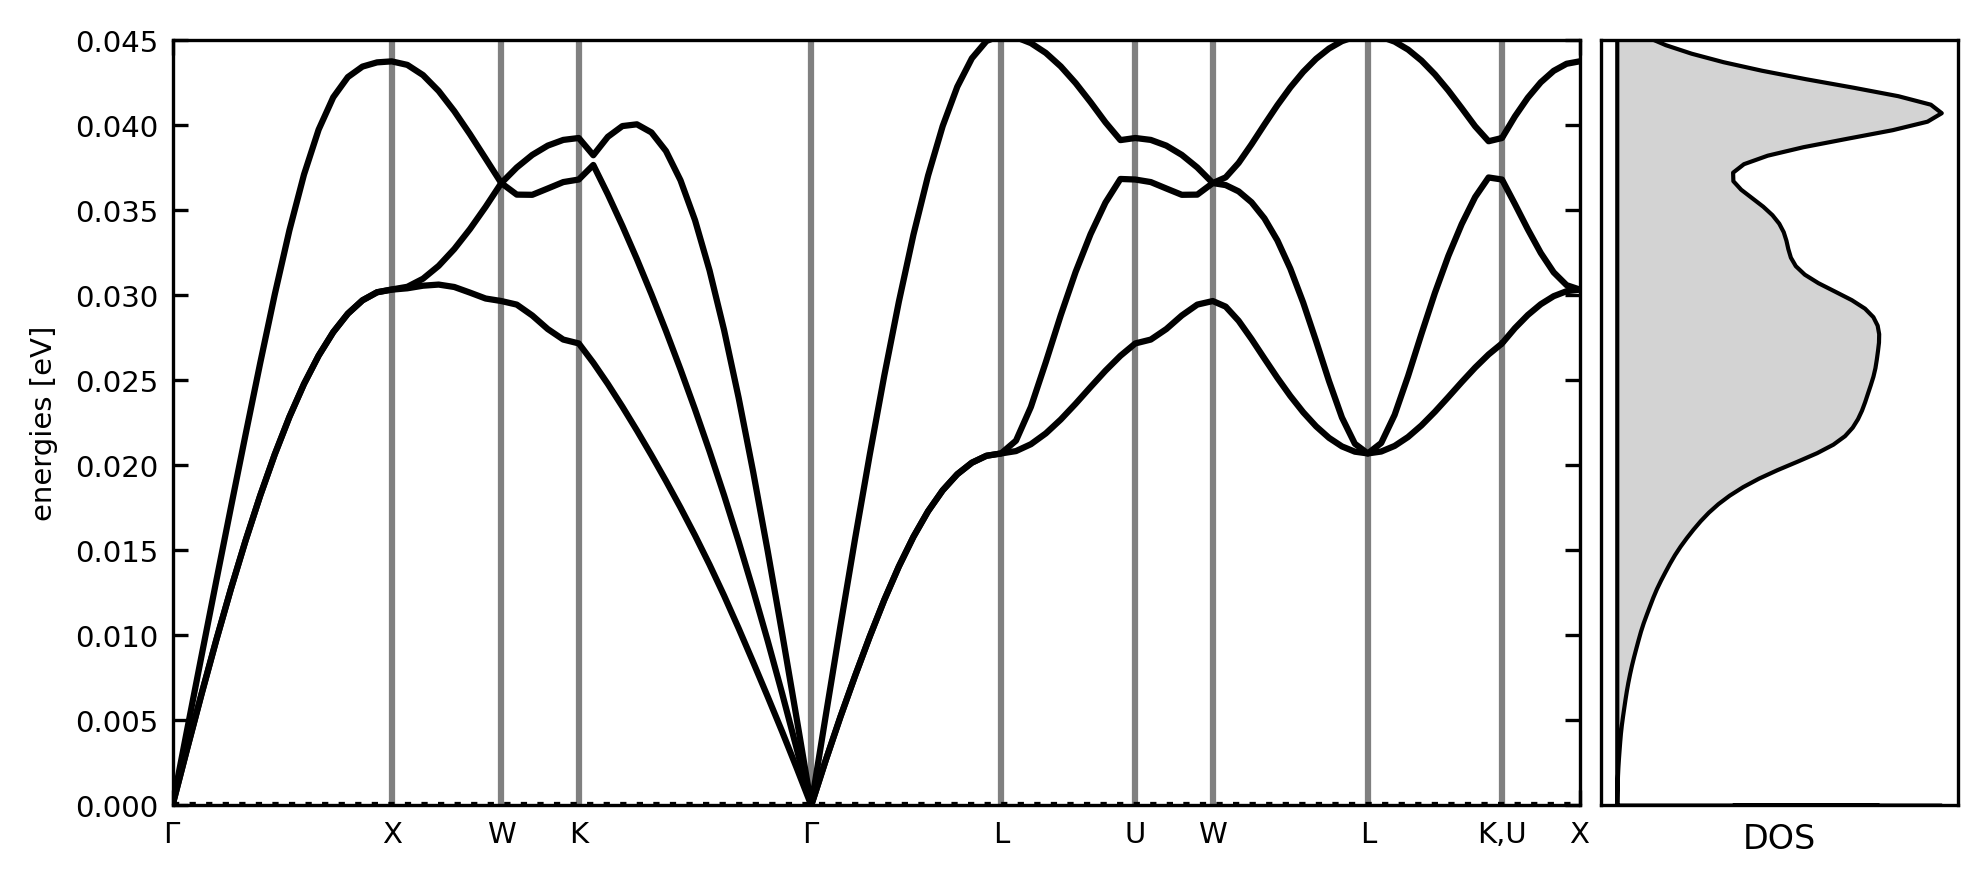

In [160]:
path = Al.cell.bandpath(npoints=100)
bs = ph.get_band_structure(path, verbose=False)
dos = ph.get_dos(kpts=(20, 20, 20), verbose=False).sample_grid(npts=100, width=1e-3)

fig = plt.figure(1, figsize=(7, 3))
ax = fig.add_axes([.12, .07, .67, .85])

emax = 0.045
bs.plot(ax=ax, emin=0.0, emax=emax, color="k")

dosax = fig.add_axes([.8, .07, .17, .85])
dosax.fill_between(
    dos.get_weights(), dos.get_energies(), 
    y2=0, color='lightgrey',
    edgecolor='k', lw=1
)

dosax.set_ylim(0, emax)
dosax.set_yticks([])
dosax.set_xticks([])
dosax.set_xlabel("DOS", fontsize=8)

plt.show()

Now repeat the same workflow using a **foundation model**, loaded here via `grace_fm("GRACE-1L-OAM")`. This model has been pre-trained on a large and diverse database of materials, and is intended to be generally applicable with minimal or no system-specific refitting.

1. rebuild the fcc Al structure,
2. relax it with the foundation model and `BFGS + FrechetCellFilter`, and
3. recompute the phonon band structure and DOS on the same grid and with the same settings as before.

This ensures that any differences we observe arise from the models themselves, not from changes in the workflow.

In [155]:
#TODO: repeat the analysis with the foundation model instead.
Al2 = pr.create.structure.bulk("Al")

Al2.calc = calc_grace

# perform a geometry optimisation while relaxing the cell and atomic positions
BFGS(FrechetCellFilter(Al2)).run()

      Step     Time          Energy          fmax
BFGS:    0 17:53:28       -3.746266        0.073596
BFGS:    1 17:53:30       -3.746461        0.049487


np.True_

In [158]:
from ase.phonons import Phonons

N = 7
ph2 = Phonons(Al2, calc_grace, supercell=(N, N, N), delta=0.05)
ph2.run()
ph2.read(acoustic=True)
ph2.clean()

7

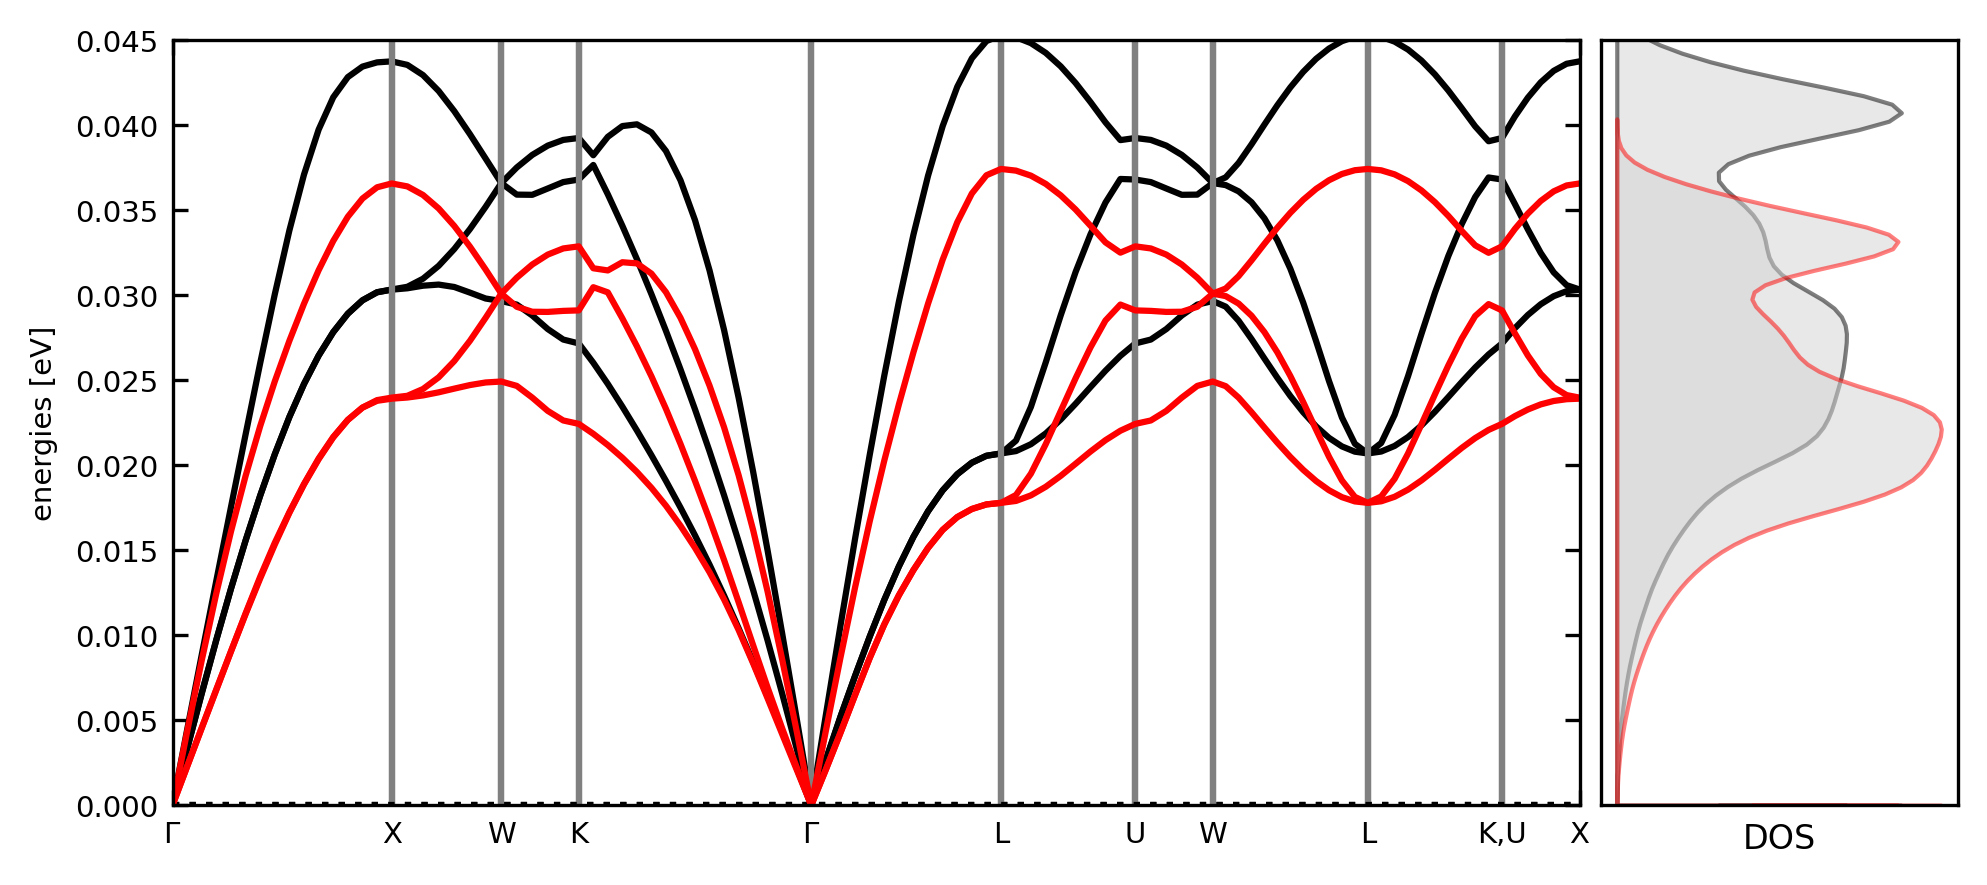

In [165]:
#TODO: plot the results. ideally, overlay the two plots so you can more clearly see the differences.
path = Al.cell.bandpath(npoints=100)
bs = ph.get_band_structure(path, verbose=False)
dos = ph.get_dos(kpts=(20, 20, 20), verbose=False).sample_grid(npts=100, width=1e-3)


path2 = Al2.cell.bandpath(npoints=100)
bs2 = ph2.get_band_structure(path, verbose=False)
dos2 = ph2.get_dos(kpts=(20, 20, 20), verbose=False).sample_grid(npts=100, width=1e-3)

fig = plt.figure(1, figsize=(7, 3))
ax = fig.add_axes([.12, .07, .67, .85])

emax = 0.045
bs.plot(ax=ax, emin=0.0, emax=emax, color="k")
bs2.plot(ax=ax, emin=0.0, emax=emax, color="r")

dosax = fig.add_axes([.8, .07, .17, .85])
dosax.fill_between(
    dos.get_weights(), dos.get_energies(), 
    y2=0, color='lightgrey',alpha=0.5,
    edgecolor='k', lw=1
)

dosax.fill_between(
    dos2.get_weights(), dos2.get_energies(), 
    y2=0, color='lightgrey',alpha=0.5,
    edgecolor='r', lw=1
)

dosax.set_ylim(0, emax)
dosax.set_yticks([])
dosax.set_xticks([])
dosax.set_xlabel("DOS", fontsize=8)

plt.show()